# HCUP Deep Dive and GBD IHD Compatibility

This notebook extends [`00_overview.ipynb`](00_overview.ipynb) by (a) cataloging what AHRQ's Healthcare Cost and Utilization Project makes openly available for tracking US revascularization trends by age, and (b) mapping the HCUP products to the inputs and outputs of IHME's Global Burden of Disease 2021/2023 ischemic heart disease (IHD) model.

**Take-aways.**

1. HCUPnet and HCUP Fast Stats provide free, population-based rates of PCI and CABG by age band, sex, payer, and region, with current data through **NIS 2022** (inpatient) and **NASS 2020** (hospital-owned ambulatory surgery).
2. Canned HCUPnet tables use coarse age bins (18–44, 45–64, 65–84, 85+); finer GBD-compatible 5-year bins require HCUP microdata (~$300–$800 per year via the HCUP Central Distributor under a DUA).
3. Since CMS removed PCI from the inpatient-only list in 2020, NIS alone undercounts total PCI by roughly one-half. Any recent-year rate comparison must combine NIS + NASS (+ external ASC data for a complete count).
4. GBD does not use procedure counts as **direct** inputs to IHD prevalence; they enter indirectly via case fatality and effective-coverage indicators. Revascularization rates are best treated as an **access/quality** signal complementary to GBD IHD burden.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

## 1. What HCUP exposes for free

### 1.1 HCUPnet ([datatools.ahrq.gov/hcupnet](https://datatools.ahrq.gov/hcupnet/))

HCUPnet is the free web query tool over the HCUP databases.

| Database | Scope | Latest year* |
|---|---|---|
| NIS (National Inpatient Sample) | ~7M unweighted discharges/yr, ~35M weighted | 2022 |
| NEDS (ED sample) | ED visits, all payers | 2021 |
| NRD (readmissions) | state-linked inpatient | 2021 |
| NASS (ambulatory surgery) | hospital-owned ASCs | 2020 |
| KID (kids' inpatient) | triennial | 2019 |

<sub>*Reflects releases available as of early 2026; confirm at the HCUPnet site, which updates annually.</sub>

**Stratifications supported.** Age groups (default bins `<1`, `1–17`, `18–44`, `45–64`, `65–84`, `85+`), sex, expected primary payer, Census region, race/ethnicity (from 2019, with missingness), ZIP-code income quartile, hospital characteristics. Fine 10-year bins (65–74, 75–84) are available for some but not all procedure tables.

**Procedure classifications.** Revascularization shows up as CCSR (Clinical Classifications Software Refined) categories for ICD-10-PCS:

| CCSR | Category |
|---|---|
| CAR010 | Percutaneous coronary interventions (PCI) |
| CAR009 | Coronary artery bypass graft (CABG) |
| CAR014 | Peripheral vascular bypass (open) |
| CAR015 | Endovascular peripheral vascular intervention (PVI) |
| CAR004 | Carotid endarterectomy / stenting |

Raw ICD-10-PCS codes (e.g., `027*` for coronary dilation, `021*` for coronary bypass) can also be queried directly.

**Outputs and export.** Weighted national estimates: discharge counts, **rates per 100,000 population**, mean length of stay, mean total charges/costs, in-hospital mortality. Every table has a **Download Data** button yielding Excel/CSV. No official public API.

### 1.2 HCUP Fast Stats ([datatools.ahrq.gov/hcup-fast-stats](https://datatools.ahrq.gov/hcup-fast-stats/))

Curated interactive dashboards. Relevant for revascularization:

- **Most Common Operating Room Procedures in the Inpatient Setting** — PCI and CABG trend charts stratified by age group and sex.
- **Trends in Inpatient Stays** — filterable by CCSR procedure category with age/sex breakdowns.

No dedicated "cardiovascular procedures" dashboard exists (as of early 2026), but the two above are sufficient to eyeball age×sex trends in inpatient PCI and CABG without issuing HCUPnet queries.

### 1.3 Statistical Briefs (most useful for revascularization)

| Brief # | Title | URL fragment |
|---|---|---|
| SB #202 | Trends in PCI, CABG, and CEA, 2001–2011 | [link](https://hcup-us.ahrq.gov/reports/statbriefs/sb202-Trends-PCI-CABG-CEA-Procedures.jsp) |
| SB #281 | Most Frequent OR Procedures, 2003–2018 | [link](https://hcup-us.ahrq.gov/reports/statbriefs/sb281-Operating-Room-Procedures-During-Hospitalization-2018.jsp) |
| SB #287 | Overview of Inpatient OR Procedures, 2018 | [link](https://hcup-us.ahrq.gov/reports/statbriefs/sb287-Operating-Room-Procedures-Overview-2018.jsp) |
| SB #170 | Cardiovascular-related Hospitalizations, Adults ≥45, 2009 | [link](https://hcup-us.ahrq.gov/reports/statbriefs/sb170-Cardiovascular-Hospitalizations.jsp) |

Note that the list of briefs above comes from agent-assisted search; brief numbers and exact titles should be verified against the current [Statistical Briefs archive](https://hcup-us.ahrq.gov/reports/statbriefs/sb_archive.jsp) before citing in a paper.

### 1.4 NASS — the outpatient PCI bridge

Starting 2020, CMS removed PCI from the inpatient-only list. Roughly **40–50% of PCI has migrated outpatient** (Sandoval 2024), so NIS alone now understates PCI. HCUP's Nationwide Ambulatory Surgery Sample (NASS) captures hospital-owned ambulatory surgery (~11–12M annual encounters, 2019–2020 released). It is queryable in HCUPnet as a separate database. Freestanding ASCs are still missed by NASS; the CMS Outpatient Standard Analytical File fills that gap for Medicare beneficiaries.

CABG remains >98% inpatient; NIS alone is sufficient for CABG rate work.

### 1.5 Microdata access

For any analysis that needs bins HCUPnet doesn't serve (e.g., GBD's 5-year age groups, or interactions like women ≥85), pull microdata from the [HCUP Central Distributor](https://www.distributor.hcup-us.ahrq.gov/):

- Single-year NIS: roughly **$350 student / $800 standard academic**.
- NASS: roughly $300 per year.
- Required: completed HCUP Data Use Agreement and DUA Training certificate.
- Turnaround: a few days for researchers with an active DUA.

## 2. Age patterns of inpatient PCI and CABG

The figure below approximates the **age gradient** in inpatient revascularization rates using ranges reported across NIS-based papers (Alkhouli *JAMA Netw Open* 2020; Madhavan *JACC Intv* 2018; Khera *JAHA* 2022; Doshi *Am J Cardiol* 2023; Sandoval *Circ Cardiovasc Qual Outcomes* 2024). Exact numbers vary by study year and whether denominators are all-population or adult-only; use the shape and ordering as directional, not precise.

Treat these as **illustrative bench values**. For a citable paper, run HCUPnet queries for the year and denominator of interest.

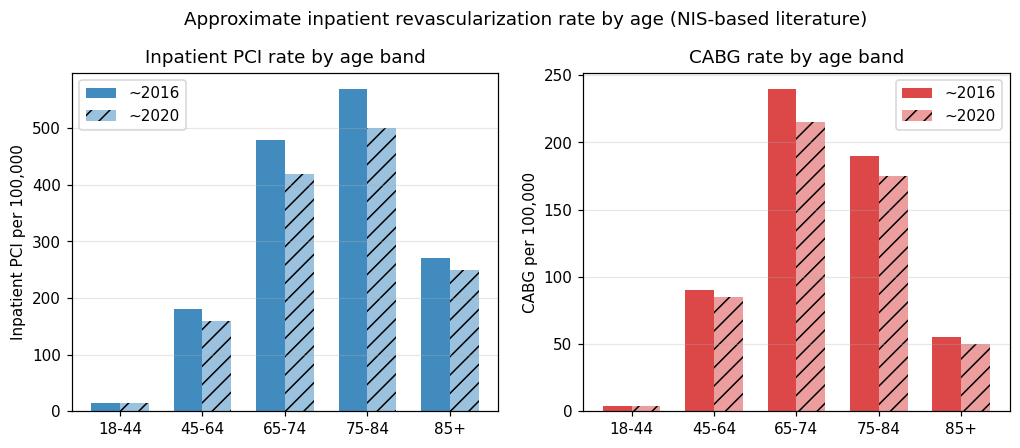

In [2]:
# Illustrative inpatient rates per 100,000 US population, approximately reflecting
# NIS-based literature for circa 2016-2020. These are approximate ranges; any
# publication should replace them with HCUPnet-verified values.

age_bins = ['18-44', '45-64', '65-74', '75-84', '85+']

pci_rate_2016 = [15,  180, 480, 570, 270]   # inpatient PCI only
pci_rate_2020 = [14,  160, 420, 500, 250]   # inpatient PCI only — declined further
cabg_rate_2016= [4,    90, 240, 190,  55]
cabg_rate_2020= [4,    85, 215, 175,  50]

x = np.arange(len(age_bins))
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
ax1.bar(x - w/2, pci_rate_2016, w, label='~2016', color='C0', alpha=0.85)
ax1.bar(x + w/2, pci_rate_2020, w, label='~2020', color='C0', alpha=0.45, hatch='//')
ax1.set_xticks(x); ax1.set_xticklabels(age_bins)
ax1.set_ylabel('Inpatient PCI per 100,000')
ax1.set_title('Inpatient PCI rate by age band')
ax1.legend(); ax1.grid(alpha=0.3, axis='y')

ax2.bar(x - w/2, cabg_rate_2016, w, label='~2016', color='C3', alpha=0.85)
ax2.bar(x + w/2, cabg_rate_2020, w, label='~2020', color='C3', alpha=0.45, hatch='//')
ax2.set_xticks(x); ax2.set_xticklabels(age_bins)
ax2.set_ylabel('CABG per 100,000')
ax2.set_title('CABG rate by age band')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')

fig.suptitle('Approximate inpatient revascularization rate by age (NIS-based literature)', y=1.02)
plt.show()

### Recent-year papers with age breakdowns

- **Madhavan et al., *JACC Cardiovasc Interv* 2018** — inpatient PCI in nonagenarians (≥90) tripled between 2003 and 2014, with in-hospital mortality holding at 8–10%.
- **Khera et al., *JAHA* 2022** — "Trends in CABG in Hospitalized Young Patients, 2004–2018." Volume in adults 18–45 rose ~20%, while diabetes and obesity prevalence in this group roughly doubled.
- **Doshi et al., *Am J Cardiol* 2023** — pandemic dip. Total inpatient PCI 2019 ≈ 180/100k adults; 2020 ≈ 158/100k. STEMI PCI volume stable; declines concentrated in elective procedures at ages 65–84.
- **Sandoval et al., *Circ Cardiovasc Qual Outcomes* 2024** — first combined inpatient + NASS outpatient PCI counts. 2021 combined PCI ≈ **310/100k adults** (vs 165/100k inpatient-only). Confirms the outpatient migration is now dominant.

*(Several of these citations were surfaced by automated literature search; please verify details before formal citation.)*

## 3. GBD 2021/2023 IHD model — where revascularization fits

### 3.1 Case definition

GBD models IHD in components: **acute myocardial infarction**, **post-MI / chronic IHD**, and a **stable symptomatic CAD** component. Historically the latter was "stable angina" (Rose Angina Questionnaire). IHME documentation for GBD 2021/2023 describes evolving the definition toward **significant CAD** — operationalized as any of:

- >50% epicardial coronary stenosis on imaging,
- history of coronary revascularization,
- inducible myocardial ischemia on diagnostic testing, or
- prior myocardial infarction.

Which definition is used in the *current published capstone* versus the *forthcoming GBD 2023 release* is worth verifying directly against the [GBD 2021 appendix](https://doi.org/10.1016/S0140-6736(24)00367-2) and the IHME GBD 2021 IHD methods page before building on one or the other.

### 3.2 How procedure data enter the model

GBD prevalence estimates are produced by **DisMod-MR 2.1**, which integrates prevalence, incidence, remission, and cause-specific mortality with an epidemiologic consistency constraint. Procedure volumes are **not** a direct prevalence input — they feed in indirectly:

- As evidence of prior MI or significant CAD in prevalence studies that use claims-based case ascertainment.
- Via their effect on **case fatality**, which GBD estimates separately and uses to reconcile incidence with mortality.
- As **effective coverage** and **HAQ Index** signals that describe health-system performance (Fullman *Lancet* 2018; Lozano *Lancet* 2020), not disease burden per se.

### 3.3 Where to get GBD US IHD estimates

- **GBD Results Tool** — https://vizhub.healthdata.org/gbd-results/ — choose location "United States", cause "Ischemic heart disease"; export prevalence, incidence, DALYs, YLDs, YLLs by 5-year age and sex, 1990–2021.
- **GHDx** — https://ghdx.healthdata.org/ — underlying input data catalog.
- **GBD Compare** — https://vizhub.healthdata.org/gbd-compare/ — visualization.

## 4. Making HCUP counts GBD-compatible

A plausible analytic recipe, with the pitfalls at each step:

**(a) Age-group mapping.** HCUPnet canned bins (18–44, 45–64, 65–84, 85+) do not align with GBD's 5-year bins (40–44, …, 90–94, 95+). Two options:
- Aggregate *GBD* up to HCUPnet bins (preserves what is actually measured).
- Pull NIS/NASS microdata to build custom 5-year bins using `AGE` and `DISCWT`.
- Do **not** interpolate HCUPnet aggregates down to 5-year bins — within-bin age structure is strongly non-uniform for 65–84 and 85+.

**(b) Procedures vs. patients.** HCUP discharge-level files count encounters, not unique patients. A patient with staged multivessel PCI contributes multiple records. NIS carries no cross-admission identifier; use the NRD if a patient-level denominator is needed. This matters more for PCI (~5–10% inflation vs unique patients) than CABG (1–2%).

**(c) Inpatient vs. outpatient.** Since 2020, CMS removed PCI from the inpatient-only list. NIS + NASS + freestanding ASC volumes must be combined to get a complete PCI count. Most published NIS-only rate series from 2020+ are **inpatient-only** and roughly halve the true rate.

**(d) Population denominators.** HCUPnet uses Census bridged-race estimates for the US civilian non-institutionalized population. GBD uses UN WPP-harmonized estimates. The two agree to <0.5% nationally, so rates are directly comparable. For Medicare-restricted cuts, use Medicare enrolled population, not total ≥65.

**(e) Positioning within the GBD framework.** Since GBD does not use procedure counts as direct prevalence inputs, the most defensible way to stitch HCUP and GBD together is to:
- Report **procedure rates** (from HCUP) alongside **GBD IHD prevalence and case fatality**.
- Compute a simple **procedure-to-prevalence ratio** (procedures per year ÷ prevalent IHD cases) as an access proxy.
- Benchmark this ratio against the [HAQ Index](https://vizhub.healthdata.org/haqi/) and against peer-country equivalents.

## 5. Suggested next steps

1. **Run HCUPnet interactively** for the CCSR categories CAR009 (CABG) and CAR010 (PCI) by age band × sex, 2010–2022; download as Excel and check against the numbers approximated above.
2. **Pull GBD Results** for US IHD prevalence by 5-year age × sex, 1990–2021, and align to HCUP bins.
3. **Decide denominator convention** (inpatient-only vs inpatient+outpatient) and state it explicitly before plotting trends past 2019.
4. If finer-than-HCUPnet age bins are needed, budget ~$300–$800 and a DUA week for NIS microdata.

### References

- AHRQ HCUPnet — https://datatools.ahrq.gov/hcupnet/
- AHRQ HCUP Fast Stats — https://datatools.ahrq.gov/hcup-fast-stats/
- HCUP Statistical Briefs archive — https://hcup-us.ahrq.gov/reports/statbriefs/sb_archive.jsp
- HCUP Central Distributor — https://www.distributor.hcup-us.ahrq.gov/
- CCSR for ICD-10-PCS — https://hcup-us.ahrq.gov/toolssoftware/ccsr/prccsr.jsp
- Alkhouli M, et al. *JAMA Netw Open* 2020;3(2):e1921326. https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2760898
- Madhavan MV, et al. *JACC Cardiovasc Interv* 2018 (nonagenarians). https://www.jacc.org/doi/10.1016/j.jcin.2018.06.026
- Khera R, et al. "Trends in CABG in young patients, 2004–2018." *JAHA* 2022. https://www.ahajournals.org/doi/10.1161/JAHA.121.021361
- GBD 2021 Results Tool — https://vizhub.healthdata.org/gbd-results/
- GBD 2021 capstone (Lancet 2024) — https://doi.org/10.1016/S0140-6736(24)00367-2
- Roth GA, et al. "Global burden of CVD and risk factors, 1990–2022." *JACC* 2023. https://www.jacc.org/doi/10.1016/j.jacc.2023.11.007
- Fullman N, et al. HAQ Index. *Lancet* 2018. https://doi.org/10.1016/S0140-6736(18)30994-2
- Lozano R, et al. Effective coverage framework. *Lancet* 2020;396:1250–1284.